In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/sv1_cumulative_lrg.fits'))
# deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

deep = deep.copy()
# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*deep['Z']))
deep['q_deep'] = ((deep['DELTACHI2']>d) & (deep['DELTACHI2']>10)) | (deep['DELTACHI2']>30)
deep['q_deep'] &= deep['Z']<1.4
deep['q_deep'] &= deep['ZWARN']<1.4

# Require a minimum depth
min_depth = 3000.
mask = deep['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

COADD_FIBERSTATUS 46403 8832 0.15989861500859961
No data 45392 1011 0.021787384436351098
LRG mask 41301 4091 0.09012601339443074
Remove QSO targets 39607 1694 0.041015956030120336
39471 39471
Min depth 30607 8864 0.7754300625775886


In [4]:
nominal = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/sv1_1x_depth_lrg.fits'))
# nominal = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_1x_depth_lrg.fits'))
nominal['EFFTIME_ELG'] = 8.60 * nominal['TSNR2_ELG']
nominal['EFFTIME_LRG'] = 12.15 * nominal['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = nominal['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
nominal = nominal[mask]

# Remove "no data" fibers
mask = nominal['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
nominal = nominal[mask]

# Apply LRG mask
mask = nominal['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
nominal = nominal[mask]

# Remove QSO targets
mask = nominal['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
nominal = nominal[mask]

# Require a minimum depth
min_depth = 800.
mask = nominal['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
nominal = nominal[mask]

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*nominal['Z']))
nominal['q'] = ((nominal['DELTACHI2']>d) & (nominal['DELTACHI2']>10)) | (nominal['DELTACHI2']>30)
nominal['q'] &= nominal['Z']<1.4
nominal['q'] &= nominal['ZWARN']<1.4

mask = nominal['main_lrg'].copy()
print('Main LRGs', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
nominal = nominal[mask]

FIBERSTATUS 27179 4874 0.15206064954918416
No data 27179 0 0.0
LRG mask 25072 2107 0.07752308767798669
Remove QSO targets 24557 515 0.020540842373962986
Min depth 23201 1356 0.9447815286883577
Main LRGs 6280 16921 0.27067798801775783


In [6]:
lowsp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/sv1_low_speed_lrg.fits'))
# lowsp = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_lowspeed_lrg.fits'))
lowsp['EFFTIME_ELG'] = 8.60 * lowsp['TSNR2_ELG']
lowsp['EFFTIME_LRG'] = 12.15 * lowsp['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = lowsp['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
lowsp = lowsp[mask]

# Remove "no data" fibers
mask = lowsp['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
lowsp = lowsp[mask]

# Apply LRG mask
mask = lowsp['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
lowsp = lowsp[mask]

# Remove QSO targets
mask = lowsp['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
lowsp = lowsp[mask]

# Require a minimum depth
min_depth = 800.
mask = lowsp['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
lowsp = lowsp[mask]

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*lowsp['Z']))
lowsp['q'] = ((lowsp['DELTACHI2']>d) & (lowsp['DELTACHI2']>10)) | (lowsp['DELTACHI2']>30)
lowsp['q'] &= lowsp['Z']<1.4
lowsp['q'] &= lowsp['ZWARN']<1.4

mask = lowsp['main_lrg'].copy()
print('Main LRGs', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
lowsp = lowsp[mask]

FIBERSTATUS 5017 896 0.1515305259597497
No data 5017 0 0.0
LRG mask 4786 231 0.04604345226230815
Remove QSO targets 4688 98 0.020476389469285417
Min depth 4438 250 0.9466723549488054
Main LRGs 1156 3282 0.2604776926543488


In [7]:
deep_columns_old = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'DELTACHI2', 'EFFTIME_LRG', 'EFFTIME_ELG']
deep_columns_new = ['TARGETID', 'Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_LRG_deep', 'EFFTIME_ELG_deep']
deep1 = deep.copy()
deep1.rename_columns(deep_columns_old, deep_columns_new)

nominal = join(nominal, deep1[deep_columns_new], keys='TARGETID')
lowsp = join(lowsp, deep1[deep_columns_new], keys='TARGETID')

In [8]:
tileids = np.intersect1d(nominal['TILEID'], lowsp['TILEID'])
mask = np.in1d(nominal['TILEID'], tileids)
nominal = nominal[mask]
mask = np.in1d(lowsp['TILEID'], tileids)
lowsp = lowsp[mask]

In [9]:
nominal['weight'] = 1.
lowsp['weight'] = 1.

for tile in tileids:
    mask = nominal['TILEID']==tile
    if nominal['subset'][mask].max()>1:
        nominal['weight'][mask]/=nominal['subset'].max()
    mask = lowsp['TILEID']==tile
    if lowsp['subset'][mask].max()>1:
        lowsp['weight'][mask]/=lowsp['subset'].max()
        
print(np.sum(nominal['weight']))
print(np.sum(lowsp['weight']))

723.9999999999999
775.5


In [10]:
# Rejection rates
print(len(nominal), np.sum(~nominal['q']), np.sum(~nominal['q'])/len(nominal))
print(len(lowsp), np.sum(~lowsp['q']), np.sum(~lowsp['q'])/len(lowsp))

4344 82 0.018876611418047883
1156 33 0.028546712802768166


In [11]:
# Weighted rejection rates
print(np.sum(~nominal['q']*nominal['weight'])/np.sum(nominal['weight']))
print(np.sum(~lowsp['q']*lowsp['weight'])/np.sum(lowsp['weight']))

0.018876611418047886
0.025789813023855575


In [22]:
0.025789813023855575/0.018876611418047886

1.366231070434495

In [12]:
zdiff_threshold = 0.0033
nominal['fail'] = np.abs((nominal['Z'] - nominal['Z_deep'])/(1 + nominal['Z_deep'])) > zdiff_threshold
lowsp['fail'] = np.abs((lowsp['Z'] - lowsp['Z_deep'])/(1 + lowsp['Z_deep'])) > zdiff_threshold

In [13]:
# Catastrophic failure rates
print(len(nominal), np.sum(nominal['fail']), np.sum(nominal['fail'])/len(nominal))
print(len(lowsp), np.sum(lowsp['fail']), np.sum(lowsp['fail'])/len(lowsp))

4344 77 0.0177255985267035
1156 34 0.029411764705882353


In [14]:
# Weighted catastrophic failure rates
print(np.sum(nominal['fail']*nominal['weight'])/np.sum(nominal['weight']))
print(np.sum(lowsp['fail']*lowsp['weight'])/np.sum(lowsp['weight']))

0.0177255985267035
0.025789813023855575


In [23]:
0.025789813023855575/0.0177255985267035

1.4549473737094627

In [15]:
# Catastrophic failure rates of "good" redshifts
mask = nominal['q'] & nominal['fail']
print(len(nominal), np.sum(mask), np.sum(mask)/np.sum(nominal['q']))
mask = lowsp['q'] & lowsp['fail']
print(len(lowsp), np.sum(mask), np.sum(mask)/np.sum(lowsp['q']))

4344 25 0.005865790708587518
1156 11 0.009795191451469279


In [16]:
# Weighted catastrophic failure rates of "good" redshifts
mask = nominal['q'] & nominal['fail']
print(np.sum(mask*nominal['weight'])/np.sum(nominal['q']*nominal['weight']))
mask = lowsp['q'] & lowsp['fail']
print(np.sum(mask*lowsp['weight'])/np.sum(lowsp['q']*lowsp['weight']))

0.005865790708587518
0.008603573792190603


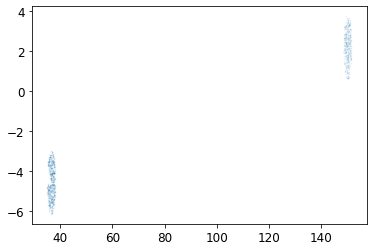

In [17]:
plt.plot(lowsp['TARGET_RA'], lowsp['TARGET_DEC'], '.', ms=1, alpha=0.1)

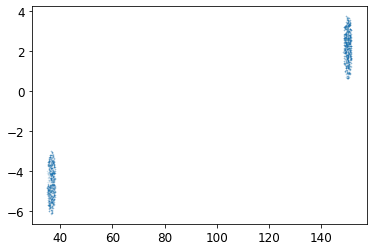

In [18]:
plt.plot(nominal['TARGET_RA'], nominal['TARGET_DEC'], '.', ms=1, alpha=0.1)

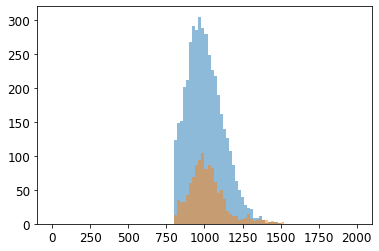

In [19]:
plt.hist(nominal['EFFTIME_LRG'], 100, range=(0, 2000), alpha=0.5)
plt.hist(lowsp['EFFTIME_LRG'], 100, range=(0, 2000), alpha=0.5)
plt.show()

In [20]:
nominal['speed'] = nominal['EFFTIME_LRG']*10**(2*2.165*nominal['EBV']/2.5)/nominal['COADD_EXPTIME']
lowsp['speed'] = lowsp['EFFTIME_LRG']*10**(2*2.165*lowsp['EBV']/2.5)/lowsp['COADD_EXPTIME']

0.65351117
0.30357257


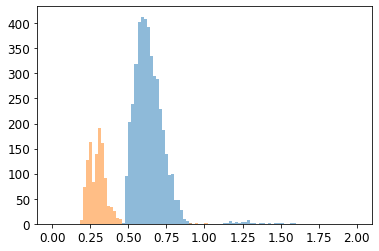

In [21]:
print(np.mean(nominal['speed']))
print(np.mean(lowsp['speed']))
plt.hist(nominal['speed'], 100, range=(0, 2), alpha=0.5)
plt.hist(lowsp['speed'], 100, range=(0, 2), alpha=0.5)
plt.show()